# 2. Qubits Basics: Qubit Visualization and Multi-Qubit Gates


In [1]:
# Core Qiskit imports
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Standard Python imports
from math import pi

# Simulator used for measurement-based examples
sim = AerSimulator()

⚠️ **Note:** Statevector shows the quantum state BEFORE measurement.
It is not random.

⚠️ **Measurement:** This is where quantum state collapses to classical results.
Randomness appears here.

# Helper Functions


In [2]:
def run_circuit_sv(qc, draw_circuit=True):
    """
    Execute a quantum circuit using Statevector.

    Teaching idea:
    - Statevector shows the quantum state BEFORE measurement.
    - QSphere is useful for visualizing basis states, probabilities, and phase.
    - Bloch sphere is most useful for ONE qubit.
    - For multiple qubits, Bloch spheres can be misleading, especially for entanglement.

    Parameters
    ----------
    qc : QuantumCircuit
        The quantum circuit to inspect.

    draw_circuit : bool
        If True, draw the circuit using matplotlib.

    Returns
    -------
    state : Statevector
        Quantum state before measurement.

    circuit_diagram :
        Circuit diagram, or None if draw_circuit=False.

    qsphere :
        QSphere visualization.

    bloch :
        Bloch sphere visualization for 1-qubit circuits.
        None for multi-qubit circuits.
    """

    # Get the quantum state directly from the circuit.
    # No measurement is needed here.
    state = Statevector.from_instruction(qc)

    # Optional: Drawing the circuit.
    circuit_diagram = qc.draw(output="mpl") if draw_circuit else None

    # QSphere works well for one or more qubits.
    qsphere = state.draw("qsphere")

    # Bloch sphere is mainly a single-qubit visualization.
    # For multi-qubit circuits, returning None avoids misleading students.
    if qc.num_qubits == 1:
        bloch = state.draw("bloch")
    else:
        bloch = None

    return state, circuit_diagram, qsphere, bloch


def run_sampling_circuit(qc, shots=1024):
    """
    Execute a circuit with measurement and return classical results.

    Teaching idea:
    - Statevector = quantum state before measurement.
    - Counts = classical results after measurement.
    - shots = number of repeated experiments.
    """

    sim = AerSimulator()

    # Keep the circuit close to what students wrote.
    # This is better for teaching than aggressive optimisation.
    compiled = transpile(qc, sim, optimization_level=0)

    # Run the circuit many times to estimate probabilities.
    result = sim.run(compiled, shots=shots).result()

    counts = result.get_counts()
    circuit_diagram = qc.draw(output="mpl")
    histogram = plot_histogram(counts)

    return counts, circuit_diagram, histogram

# Part A — Exercise 2 Foundations

This part gives students the minimum foundation before entering Chapter 6.

It focuses on:
- Statevector
- QSphere
- Bloch sphere
- X gate
- H gate
- Measurement


## 3. Example 1 — Initial Qubit State

A new qubit starts in state `|0⟩`.

This is the default starting state in Qiskit.


In [3]:
# Create a circuit with 1 qubit and no classical bit.
# We do not measure here because we want to inspect the quantum state directly.
qc = QuantumCircuit(1)

state, circuit, qsphere, bloch = run_circuit_sv(qc)

state

Statevector([1.+0.j, 0.+0.j],
            dims=(2,))


### Circuit Diagram

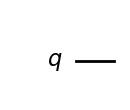

In [4]:
circuit

### QSphere

For one qubit, QSphere shows the active basis state.

Here, the state is `|0⟩`.


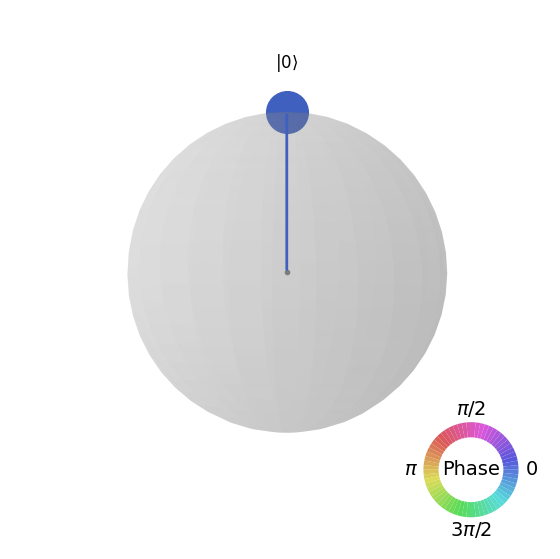

In [5]:
qsphere

### Bloch Sphere

For one qubit, Bloch sphere is very useful.

The state `|0⟩` appears at the north pole.


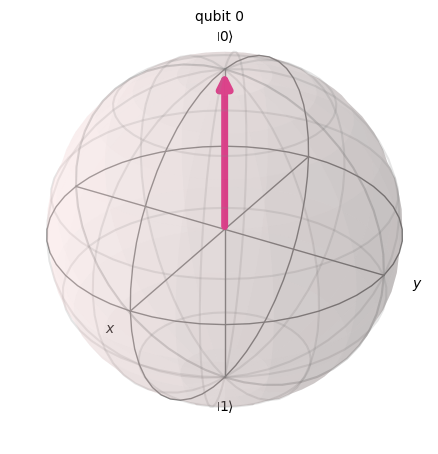

In [6]:
bloch

## 4. Example 2 — X Gate

The X gate flips the qubit:

`|0⟩ → |1⟩`

It behaves like a classical NOT gate.


In [7]:
qc = QuantumCircuit(1)

# Apply X gate to qubit 0.
qc.x(0)

state, circuit, qsphere, bloch = run_circuit_sv(qc)

state

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


### Circuit Diagram

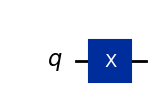

In [8]:
circuit

### QSphere

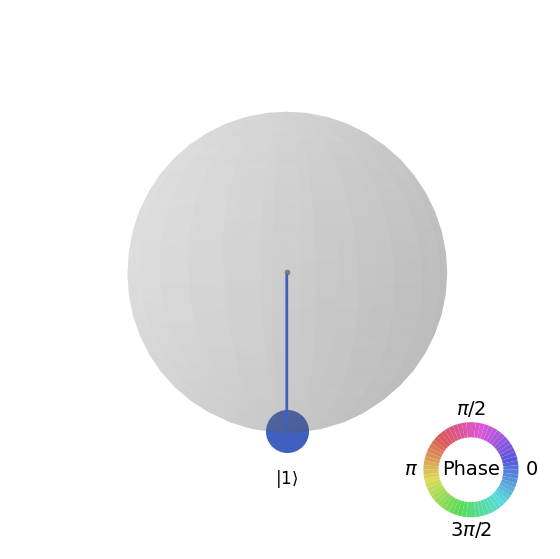

In [9]:
qsphere

### Bloch Sphere

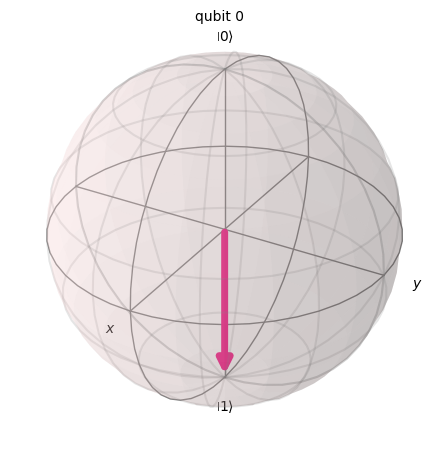

In [10]:
bloch

## 5. Example 3 — H Gate and Superposition

The H gate creates superposition:

`|0⟩ → (|0⟩ + |1⟩) / √2`

This means:
- 50% chance to measure 0
- 50% chance to measure 1

But before measurement, the qubit is not simply “random.”  
It is in a quantum superposition.


In [11]:
qc = QuantumCircuit(1)

# Apply Hadamard gate.
# This creates an equal superposition of |0⟩ and |1⟩.
qc.h(0)

state, circuit, qsphere, bloch = run_circuit_sv(qc)

state

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


### Circuit Diagram

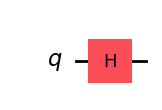

In [12]:
circuit

### QSphere

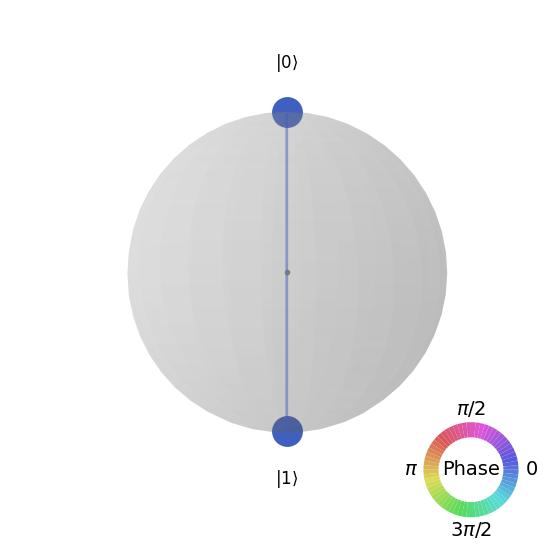

In [13]:
qsphere

### Bloch Sphere

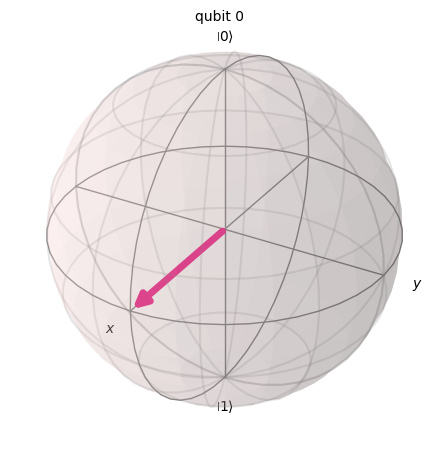

In [14]:
bloch

## Measuring a Superposition

Here we create a fresh circuit called `measured_qc`.

This name matters: the next cell uses the same variable name when sending the circuit to `AerSimulator`.


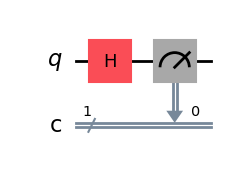

In [15]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator

# Create a new circuit with 1 qubit and 1 classical bit.
# We use the name measured_qc because the next cell will run this circuit on AerSimulator.
measured_qc = QuantumCircuit(1, 1)

# Apply H gate to create superposition:
# |0⟩ → (|0⟩ + |1⟩) / √2
measured_qc.h(0)

# Measure qubit 0 into classical bit 0.
# After measurement, the result becomes classical: either 0 or 1.
measured_qc.measure(0, 0)

# Draw the complete circuit.
measured_qc.draw(output="mpl")

⚠️ **Measurement:** This is where quantum state collapses to classical results.
Randomness appears here.

In [16]:
# Use AerSimulator for measurement outcomes.
sim = AerSimulator()

# optimization_level=0 keeps the transpiled circuit close to the original circuit.
# This is usually clearer for teaching.
compiled = transpile(measured_qc, sim, optimization_level=0)

# shots = number of repeated experiments.
# 100 is enough for classroom demonstration and is faster than 1000.
result = sim.run(compiled, shots=100).result()

# Counts show how many times each classical result appeared.
# For H + measurement, we expect roughly 50% "0" and 50% "1".
counts = result.get_counts()
counts

{'1': 43, '0': 57}

⚠️ **Measurement:** This is where quantum state collapses to classical results.
Randomness appears here.

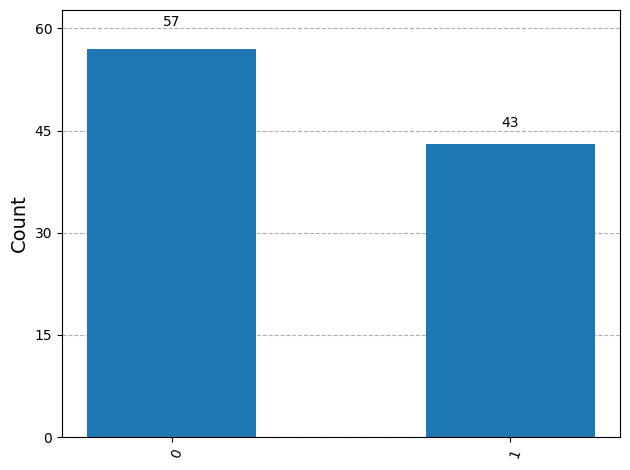

In [17]:
plot_histogram(counts)

## Important Note — Bit Ordering

Qiskit uses little-endian ordering:

```text
Rightmost bit = qubit 0
```

Example:

```text
"10"
```

means:
- qubit 1 = 1
- qubit 0 = 0

This is a common source of confusion when reading measurement results.


# Part B — Chapter 6: Understanding Multi-Qubit Gates

The following section keeps the Chapter 6 examples.

I did **not** delete the Chapter 6 examples.  
Only the first helper-file loading cell was replaced by the local helper functions above.


# Single qubit gates

In [18]:
# Hadamard gate
# H-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add an H gate to the qubit
qc.h(0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [19]:
result

Statevector([0.70710678+0.j, 0.70710678+0.j],
            dims=(2,))


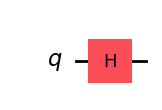

In [20]:
img

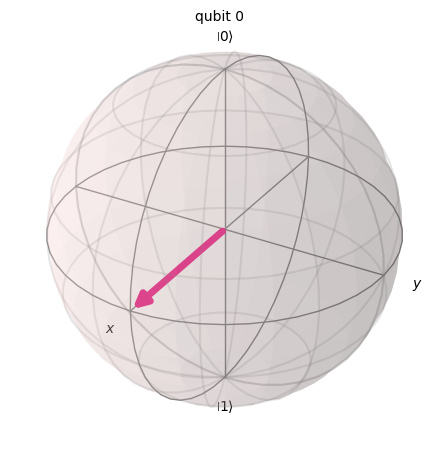

In [21]:
bloch_sphere

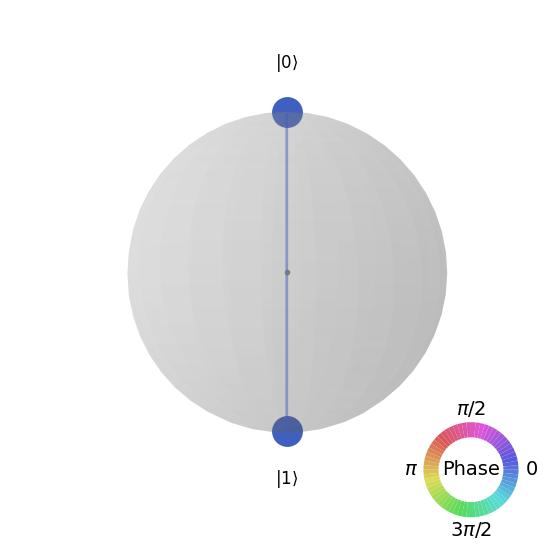

In [22]:
qsphere

In [23]:
# Pauli gate
# X-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add an X gate to the qubit
qc.x(0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [24]:
result

Statevector([0.+0.j, 1.+0.j],
            dims=(2,))


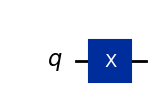

In [25]:
img

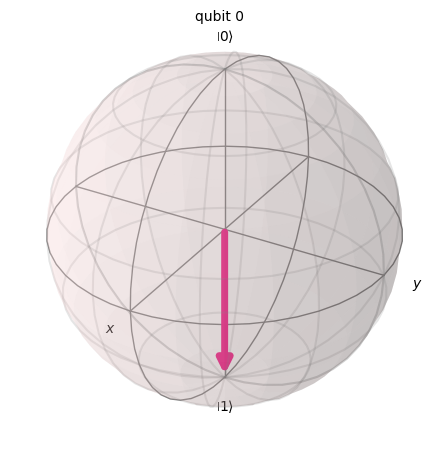

In [26]:
bloch_sphere

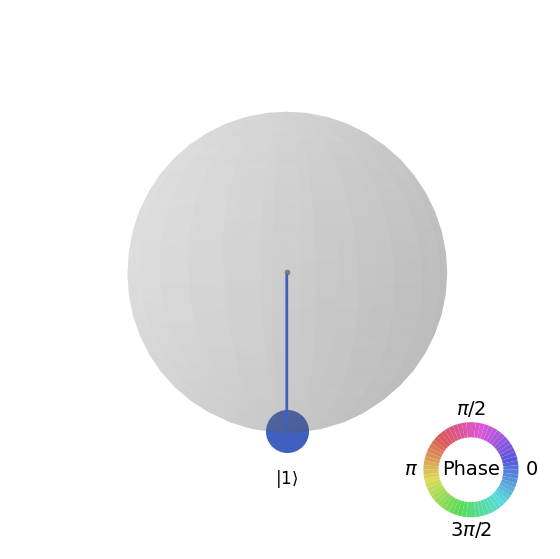

In [27]:
qsphere

In [28]:
# Pauli Y gate
# Y-gate operation on a qubit
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add a Y gate to the qubit
qc.y(0)
# Execute the circuit and capture all the results returned
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [29]:
result

Statevector([0.+0.j, 0.+1.j],
            dims=(2,))


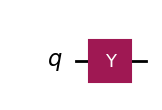

In [30]:
img

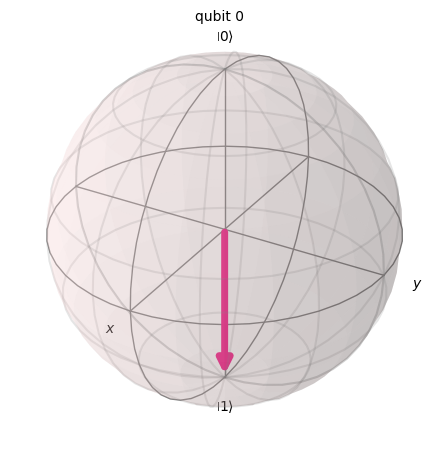

In [31]:
bloch_sphere

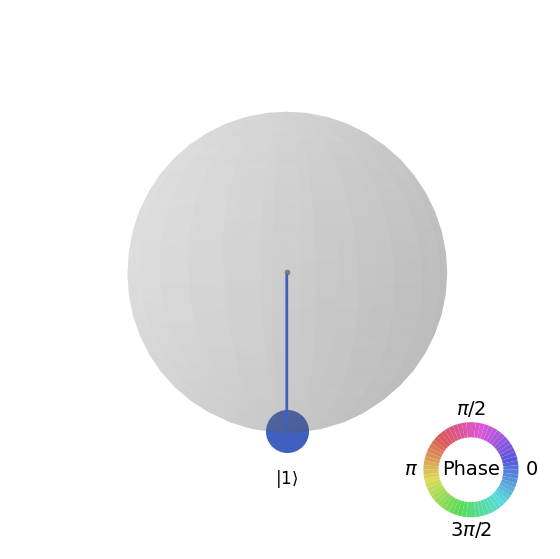

In [32]:
qsphere

In [33]:
# Pauli Z gate
# Z-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add an H gate to the qubit to set the qubit in #superposition
# Apply H gate to create superposition
qc.h(0)
# Add a Z gate to the qubit to rotate out of phase by π/2
qc.z(0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [34]:
result

Statevector([ 0.70710678+0.j, -0.70710678+0.j],
            dims=(2,))


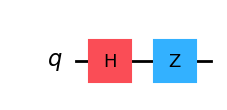

In [35]:
img

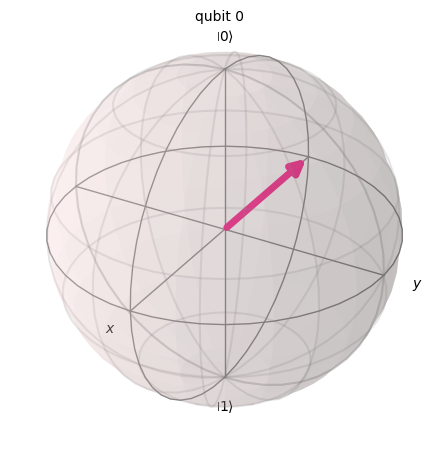

In [36]:
bloch_sphere

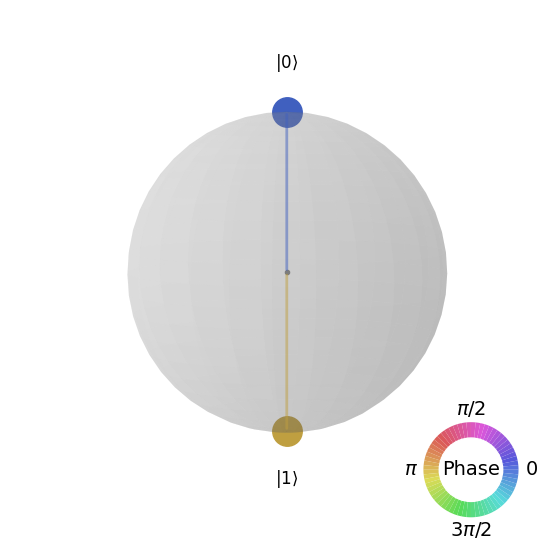

In [37]:
qsphere

In [38]:
# S-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add an H gate to the qubit to drop the vector onto the #X-axis
# Apply H gate to create superposition
qc.h(0)
# Add an S gate to the qubit
qc.s(0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [39]:
result

Statevector([0.70710678+0.j        , 0.        +0.70710678j],
            dims=(2,))


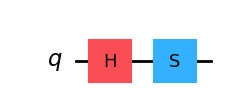

In [40]:
img

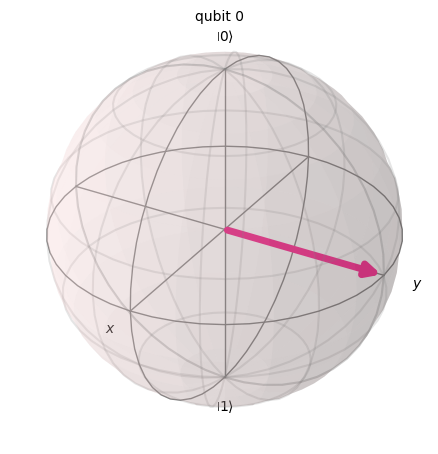

In [41]:
bloch_sphere

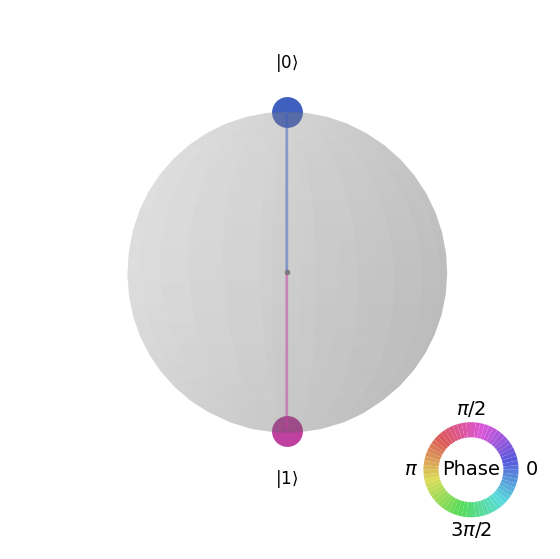

In [42]:
qsphere

In [43]:
# Sdg-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add an H gate to the qubit to drop the vector onto the #X-axis
# Apply H gate to create superposition
qc.h(0)
# Add an S† gate to the qubit
qc.sdg(0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [44]:
result

Statevector([0.70710678+0.j        , 0.        -0.70710678j],
            dims=(2,))


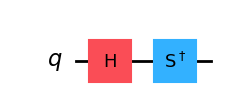

In [45]:
img

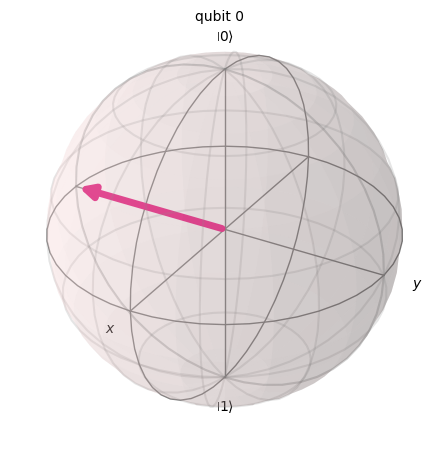

In [46]:
bloch_sphere

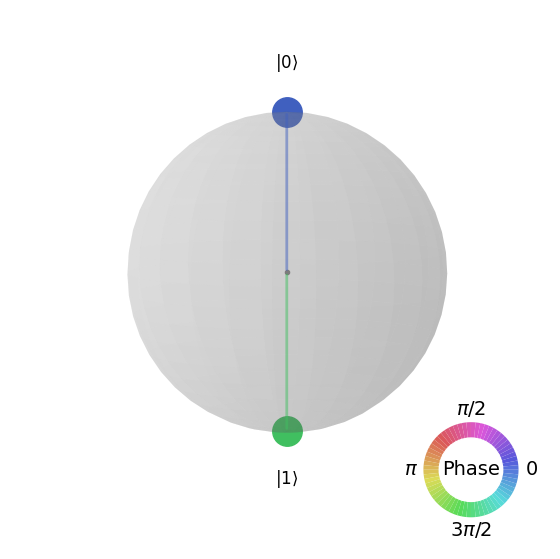

In [47]:
qsphere

In [48]:
# T-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add an H gate to the qubit to drop the vector onto the #X-axis
# Apply H gate to create superposition
qc.h(0)
# Add a T gate to the qubit
qc.t(0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [49]:
result

Statevector([0.70710678+0.j , 0.5       +0.5j],
            dims=(2,))


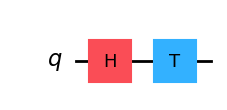

In [50]:
img

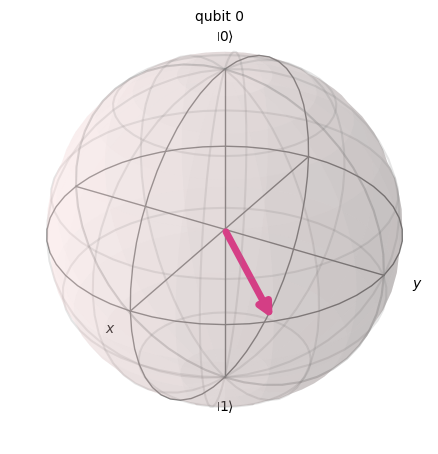

In [51]:
bloch_sphere

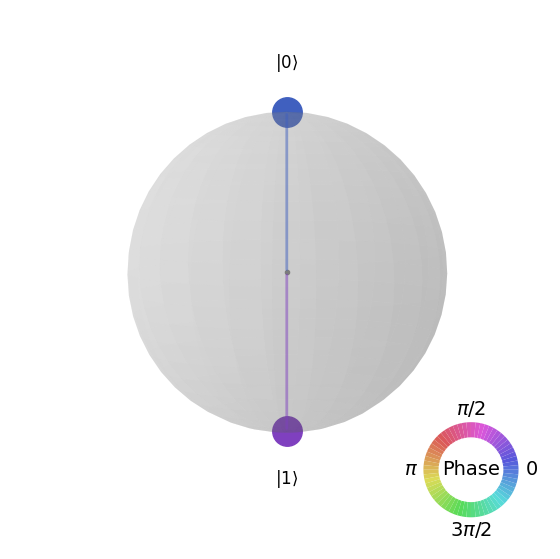

In [52]:
qsphere

In [53]:
# Tdg-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Add an H gate to the qubit to drop the vector onto the #X-axis
# Apply H gate to create superposition
qc.h(0)
# Add a Tdg gate to the qubit
qc.tdg(0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [54]:
result

Statevector([0.70710678+0.j , 0.5       -0.5j],
            dims=(2,))


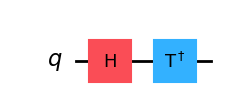

In [55]:
img

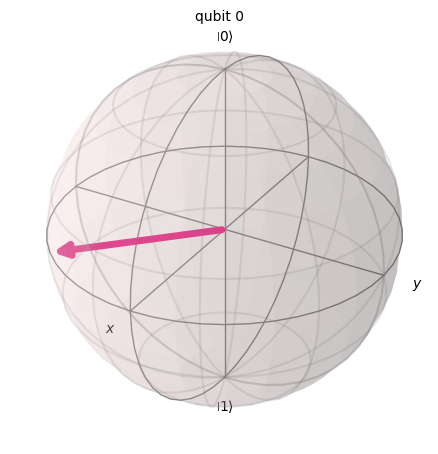

In [56]:
bloch_sphere

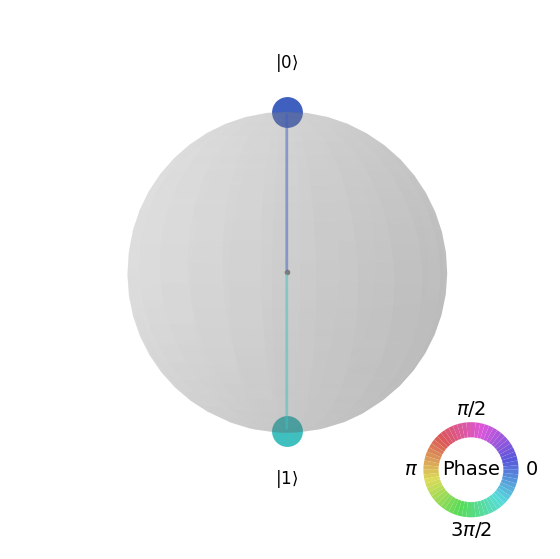

In [57]:
qsphere

In [58]:
# Rz-gate
# Create the single qubit circuit
qc = QuantumCircuit(1)
# Import pi from the math library
from math import pi

# Add an H gate to help visualize phase rotation
# Apply H gate to create superposition
qc.h(0)
# Add an RZ gate with an arbitrary angle theta of pi/6
qc.rz(pi / 6, 0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [59]:
result

Statevector([0.6830127-0.1830127j, 0.6830127+0.1830127j],
            dims=(2,))


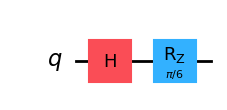

In [60]:
img

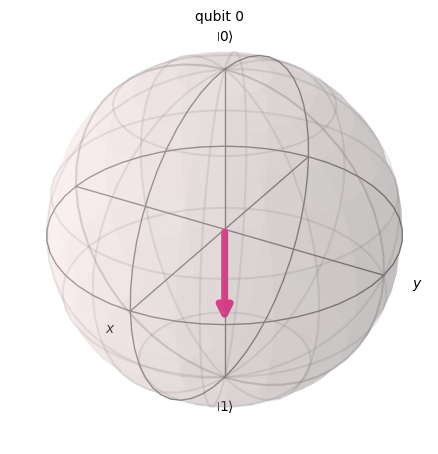

In [61]:
bloch_sphere

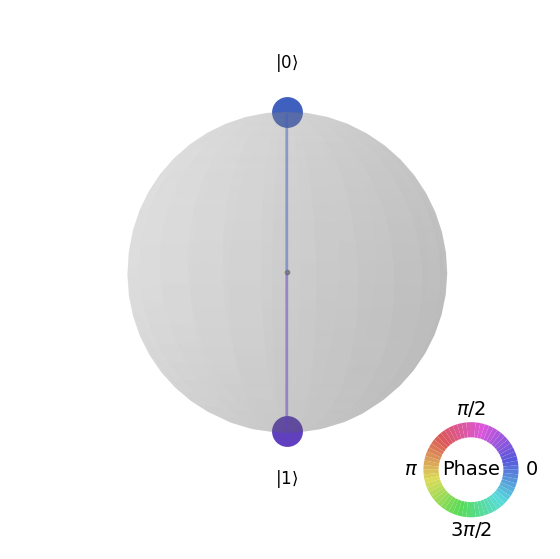

In [62]:
qsphere

In [63]:
# U-gate
from math import pi

# Create a single qubit circuit
qc = QuantumCircuit(1)
# Add a U gate and rotate all parameters by pi/2, and #apply it to the qubit
qc.u(pi / 2, pi / 2, pi / 2, 0)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [64]:
result

Statevector([7.07106781e-01+0.j        , 4.32978028e-17+0.70710678j],
            dims=(2,))


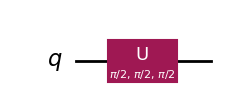

In [65]:
img

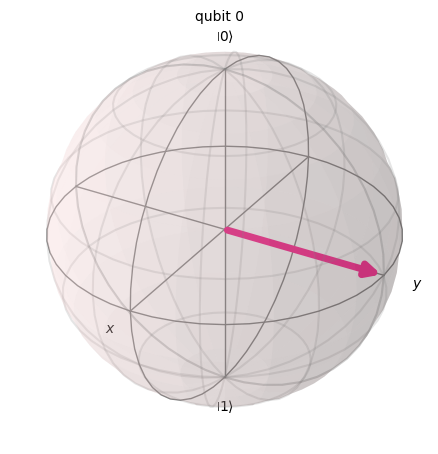

In [66]:
bloch_sphere

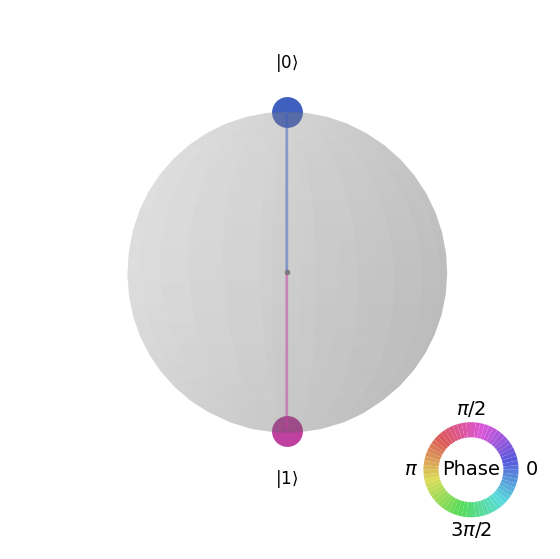

In [67]:
qsphere

# Multi-qubit gates

In [68]:
# CNOT-gate
# Create a two qubit circuit
qc = QuantumCircuit(2)
# Add an H gate to the qubit
# Apply H gate to create superposition
qc.h(0)
# Add an CNOT gate where, control = first, target = second qubit
# Apply CX: qubit 0 is control, qubit 1 is target
qc.cx(0, 1)
# Measure all qubits and send results to classical bits
qc.measure_all()
# Execute the circuit and capture all the counts
counts, img, histogram = run_sampling_circuit(qc)

⚠️ **Measurement:** This is where quantum state collapses to classical results.
Randomness appears here.

In [69]:
counts

{'11': 505, '00': 519}

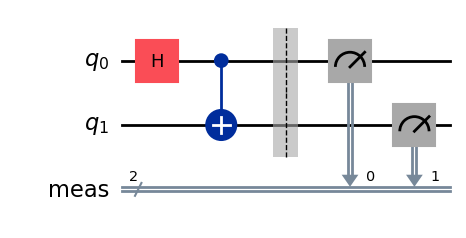

In [70]:
img

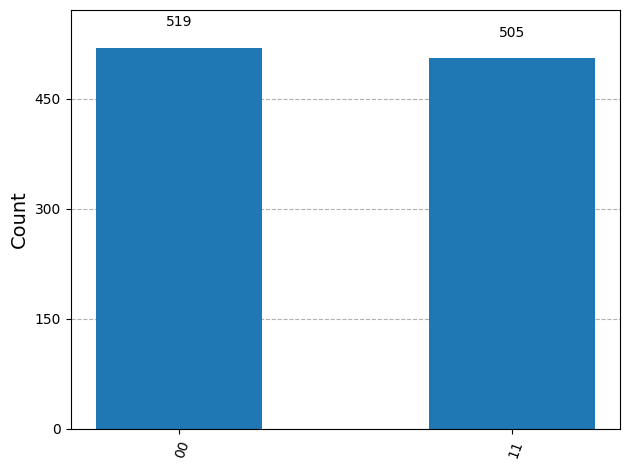

In [71]:
histogram

In [72]:
# Toffoli (CCX)-gate
# Create a three qubit circuit
qc = QuantumCircuit(3)
# Enable the Controls qubits of the Toffoli gate
qc.x(range(2))
# Add the Toffoli gate (CCX)
qc.ccx(0, 1, 2)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [73]:
print(result)

Statevector([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j,
             1.+0.j],
            dims=(2, 2, 2))


In [74]:
bloch_sphere

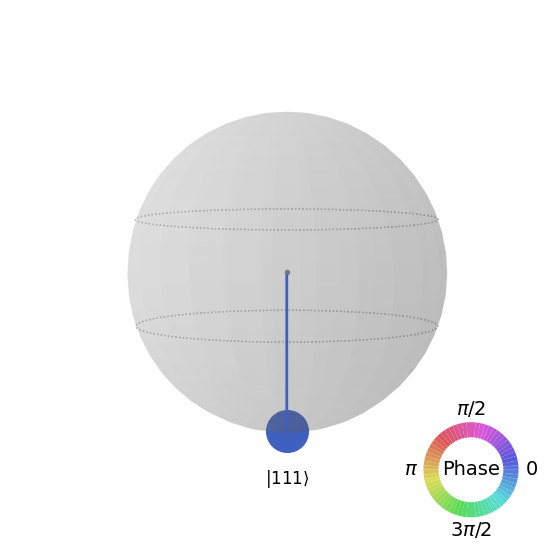

In [75]:
qsphere

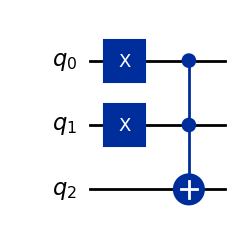

In [76]:
img

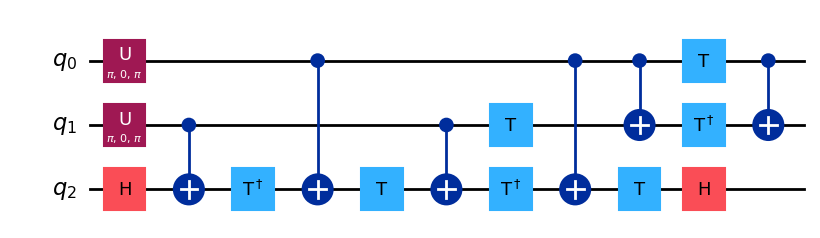

In [77]:
qc_decomposed = qc.decompose()
qc_decomposed.draw(output="mpl")

In [78]:
# Swap-gate
from math import pi

# Create a two qubit circuit
qc = QuantumCircuit(2)
# Qubit 0 is initialized to |0> state
# Prepare qubit 1 to the |1> state
qc.x(1)
# Now swap gates
qc.swap(0, 1)
# Execute the circuit and capture all the results
result, img, qsphere, bloch_sphere = run_circuit_sv(qc)

In [79]:
result

Statevector([0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
            dims=(2, 2))


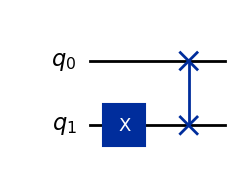

In [80]:
img

In [81]:
bloch_sphere

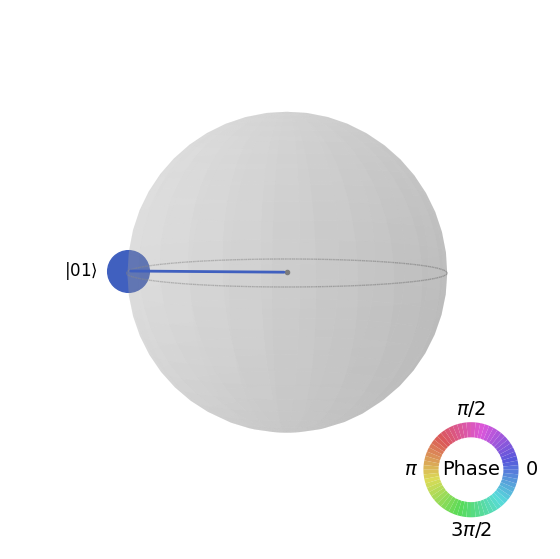

In [82]:
qsphere

# Measurement operator

In [83]:
# CNOT-gate
# Create a two qubit circuit
qc = QuantumCircuit(2)
# Add an H gate to the qubit
# Apply H gate to create superposition
qc.h(0)
# Add an CNOT gate where, control = first, target = second #qubit
# Apply CX: qubit 0 is control, qubit 1 is target
qc.cx(0, 1)
# Measure qubits and map to classical bits
qc.measure_all()
# Execute the circuit and capture all the results
result, img, histogram = run_sampling_circuit(qc)

⚠️ **Measurement:** This is where quantum state collapses to classical results.
Randomness appears here.

In [84]:
result

{'11': 509, '00': 515}

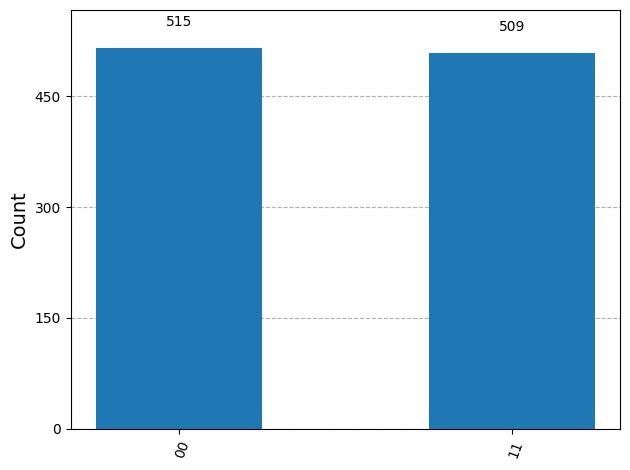

In [85]:
histogram

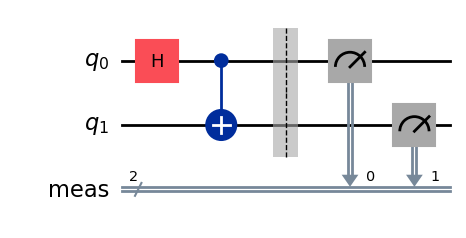

In [86]:
img

In [87]:
# Measurement operator
# Create two separate two-qubit, and two-classical bit circuits
qc1 = QuantumCircuit(2, 2)
qc2 = QuantumCircuit(2, 2)
# In the first circuit (qc1), measure qubits individually
qc1.measure(0, 0)
qc1.measure(1, 1)
# In the second circuit (qc2) measure using a list
qc2.measure([0, 1], [0, 1])
# Execute the circuit and capture all the results
result, img, histogram = run_sampling_circuit(qc1)
result2, img2, histogram2 = run_sampling_circuit(qc2)

⚠️ **Measurement:** This is where quantum state collapses to classical results.
Randomness appears here.

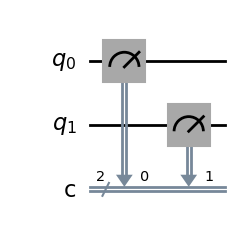

In [88]:
img

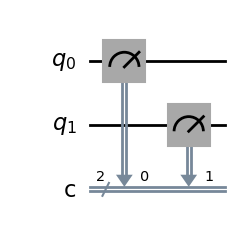

In [89]:
img2

In [90]:
# Optional version check.
# If qiskit_ibm_runtime is not installed, this cell may fail.
# It is not required for the gate examples above.

try:
    import qiskit_ibm_runtime

    qiskit_ibm_runtime.version.get_version_info()
except ImportError:
    print(
        "qiskit_ibm_runtime is not installed. You can skip this optional version-check cell."
    )

In [91]:
# Optional Qiskit version check.
import qiskit

qiskit.version.get_version_info()

'2.3.1'

In [92]:
# End of Chapter 6 examples.

# Final Teaching Summary

This combined notebook covers:

## Single-qubit ideas
- `X` gate: flip
- `H` gate: superposition
- `Y`, `Z`, `S`, `Sdg`, `T`, `Tdg`, `Rz`, `U`: phase and rotation gates
- Bloch sphere and QSphere visualizations

## Multi-qubit ideas
- `CX`: controlled NOT
- `CCX`: Toffoli gate
- `SWAP`: exchange qubit states
- Measurement mapping
- Histograms and counts

## Teaching strategy
Use this sequence in class:

1. Show the statevector first  
2. Visualize with QSphere / Bloch sphere  
3. Add measurement  
4. Move to controlled gates  
5. Explain entanglement and measurement correlations


## Teaching Note — Statevector vs Measurement

A common student confusion:

- **Statevector** = quantum state **before measurement**
- **Counts** = classical outcomes **after measurement**

So these two are not the same thing.

Statevector is like looking at the recipe.  
Measurement counts are like repeatedly baking and checking what comes out.


## Teaching Note — H Gate Is Not Just Randomness

After applying an H gate to `|0⟩`, the measurement result is approximately:

- 50% `0`
- 50% `1`

But the qubit is not simply “randomly choosing.”

Before measurement, it is in a **superposition**:

`(|0⟩ + |1⟩) / √2`

The probability comes from the quantum state.
